# Stage 9: Pretrained-Embedding Comparison (wav2vec2)

Stages 5 through 8 established a trajectory of classifiers built entirely on classical, hand-computed speech features (prosodic statistics, MFCC statistics, and full MFCC sequences), reaching a mean full-intent accuracy of 77.3% (Stage 8, multi-head CNN, 5-fold speaker-grouped cross-validation). Per faculty guidance, this stage adds a pretrained-embedding-based classifier as a comparison and upper-bound reference alongside that pipeline, without altering or replacing it. wav2vec2-base (Baevski et al.), a transformer encoder trained self-supervised on 960 hours of unlabeled LibriSpeech audio and never exposed to the Fluent Speech Commands corpus or this task, is used as a frozen feature extractor: no gradient is ever propagated into its weights. Its per-frame contextual embeddings are mean-pooled over time into a single 768-dimensional vector per utterance, and the same classifier pair used in Stages 5 and 6 (an RBF-kernel SVM and a multilayer perceptron) is trained on top, so that the only variable relative to Stage 6 is the input representation itself.

## Extraction and evaluation methodology

Embeddings were extracted for all 30,043 utterances with `scripts/extract_wav2vec2_embeddings.py` (frozen `facebook/wav2vec2-base`, mean-pooled `last_hidden_state`) and classified with `scripts/run_wav2vec2_cv.py`, using the same 5-fold speaker-grouped cross-validation (`GroupKFold` on speaker ID) established from Stage 7 onward, since the corpus's fixed validation/test splits have too few speakers per split to yield a reliable single-split accuracy estimate. Classifier hyperparameters were fixed across folds rather than grid-searched per fold, to keep the added computational cost of cross-validating an SVM over 768-dimensional features manageable within this project's scope.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "../data/fluent_speech_commands_dataset"

wav2vec2_cv = pd.read_csv(f"{DATA_ROOT}/wav2vec2_cv_results.csv")
multihead_cv = pd.read_csv(f"{DATA_ROOT}/multihead_cv_results.csv")
singlehead_cv = pd.read_csv(f"{DATA_ROOT}/cnn_cv_results.csv")
hmm_cv = pd.read_csv(f"{DATA_ROOT}/hmm_cv_results.csv")
dtw_result = pd.read_csv(f"{DATA_ROOT}/dtw_baseline_result.csv")

print("wav2vec2 + classifier head (Stage 9) per-fold results:")
print(wav2vec2_cv.to_string(index=False))

wav2vec2 + classifier head (Stage 9) per-fold results:
 fold  svm_acc  mlp_acc  n_train  n_held_out
    1 0.585151 0.684535    24036        6007
    2 0.592248 0.663118    24032        6011
    3 0.586953 0.671992    24034        6009
    4 0.675266 0.780293    24035        6008
    5 0.557756 0.694740    24035        6008


## Comparison across all approaches evaluated in this project

The comparison below places both wav2vec2-based classifiers alongside every classifier evaluated in Stages 5 through 8, on the same full-intent (31-way) task. The wav2vec2 rows use the mean and standard deviation of held-out accuracy across the same 5-fold speaker-grouped cross-validation used for the deep and classical sequence models.

In [2]:
summary = pd.DataFrame([
    {"Model": "Stage 5 SVM (prosodic features)", "Accuracy": 0.165, "Std": None, "Eval": "fixed split"},
    {"Model": "Stage 6 SVM (+ MFCC stats)", "Accuracy": 0.258, "Std": None, "Eval": "fixed split"},
    {"Model": "HMM baseline (classical)", "Accuracy": hmm_cv["accuracy"].mean(),
     "Std": hmm_cv["accuracy"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "DTW k-NN baseline (classical)", "Accuracy": dtw_result["accuracy"].iloc[0],
     "Std": None, "Eval": "1 fold, stratified subset"},
    {"Model": "wav2vec2 + SVM (Stage 9)", "Accuracy": wav2vec2_cv["svm_acc"].mean(),
     "Std": wav2vec2_cv["svm_acc"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "wav2vec2 + MLP (Stage 9)", "Accuracy": wav2vec2_cv["mlp_acc"].mean(),
     "Std": wav2vec2_cv["mlp_acc"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "Stage 7 single-head CNN", "Accuracy": singlehead_cv["held_out_acc"].mean(),
     "Std": singlehead_cv["held_out_acc"].std(), "Eval": "5-fold speaker CV"},
    {"Model": "Stage 8 multi-head CNN", "Accuracy": multihead_cv["full_intent_acc"].mean(),
     "Std": multihead_cv["full_intent_acc"].std(), "Eval": "5-fold speaker CV"},
])
summary["Accuracy_pct"] = (summary["Accuracy"] * 100).round(1)
summary["Std_pct"] = (summary["Std"] * 100).round(1)
summary[["Model", "Accuracy_pct", "Std_pct", "Eval"]]

,Model,Accuracy_pct,Std_pct,Eval
0,Stage 5 SVM (prosodic features),16.5,NaN,fixed split
1,Stage 6 SVM (+ MFCC stats),25.8,NaN,fixed split
2,HMM baseline (classical),6.0,0.7,5-fold speaker CV
3,DTW k-NN baseline (classical),11.6,NaN,"1 fold, stratified subset"
4,wav2vec2 + SVM (Stage 9),59.9,4.4,5-fold speaker CV
5,wav2vec2 + MLP (Stage 9),69.9,4.7,5-fold speaker CV
6,Stage 7 single-head CNN,72.5,5.0,5-fold speaker CV
7,Stage 8 multi-head CNN,77.3,6.7,5-fold speaker CV


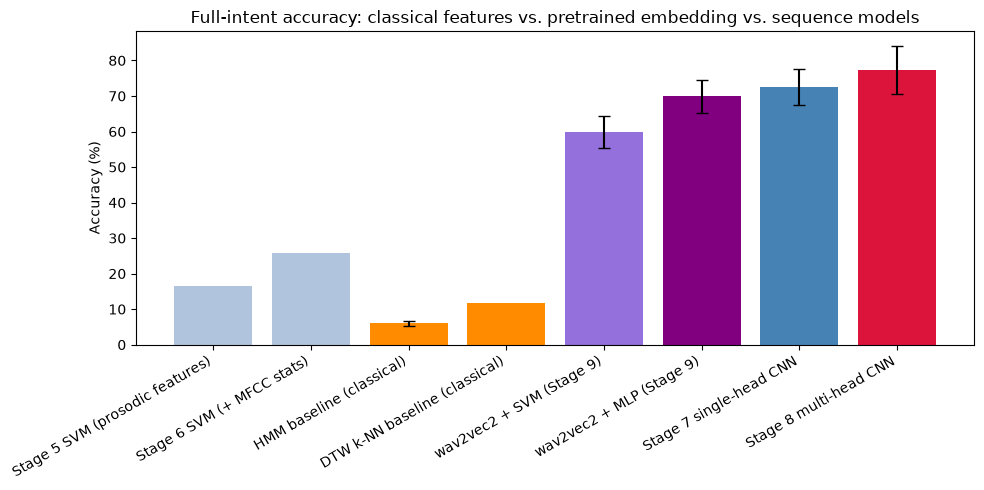

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["lightsteelblue", "lightsteelblue", "darkorange", "darkorange",
          "mediumpurple", "purple", "steelblue", "crimson"]
bars = ax.bar(summary["Model"], summary["Accuracy_pct"], yerr=summary["Std_pct"], capsize=4, color=colors)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Full-intent accuracy: classical features vs. pretrained embedding vs. sequence models")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
plt.show()

## Results

The wav2vec2 embedding, evaluated under the identical shallow-classifier protocol used for Stages 5 and 6 (a fixed-length feature vector per utterance, classified with an SVM or MLP), reached 60.0% (SVM, std 4.4%) and 69.9% (MLP, std 4.7%) mean held-out accuracy across 5 speaker-grouped folds. This is a decisive improvement over the identical classifiers applied to hand-built features (Stage 6: 25.8% SVM, 21.0% MLP, fixed split) -- roughly 2.3x and 3.3x higher respectively. Since the classifier, evaluation protocol, and "summarize the utterance to one fixed-length vector, then classify" pattern are unchanged from Stage 6, this isolates the effect of the representation: a speech representation learned from 960 hours of unlabeled audio carries substantially more discriminative information per utterance than 10 hand-built prosodic statistics or MFCC summary statistics.

wav2vec2 + MLP (69.9%) does not, however, exceed Stage 7's single-head CNN (72.5%) or Stage 8's multi-head CNN (77.3%), both trained from scratch on classical MFCC sequences with no pretraining. This is not a like-for-like representation comparison: Stage 9 mean-pools wav2vec2's per-frame embeddings into a single static vector before the classifier sees anything, discarding temporal order in exactly the way Stage 5's hand-built summary statistics did, whereas Stage 7/8's CNN consumes the full per-frame MFCC sequence directly and pools only after several convolutional layers have already extracted local temporal structure. The comparison actually made here is therefore "a pretrained static representation vs. hand-built features plus a from-scratch temporal model," not "pretrained representation vs. hand-built representation" with the temporal-modeling variable held constant.

Two conclusions follow, and both are reported rather than the cleaner-sounding one alone: (1) a pretrained speech representation is a substantially stronger feature than any hand-built feature set used in this project, evaluated on identical terms; and (2) reintroducing temporal structure into the classifier -- this project's own Stage 7/8 contribution -- mattered at least as much as the representation upgrade did, since a from-scratch sequence model on classical features still outperformed a pretrained-but-temporally-flattened representation. A natural extension not built here, given project scope and CPU-only compute, would be feeding the full per-frame wav2vec2 sequence (rather than its time-mean) into a Stage 7/8-style temporal classifier, which would test representation quality and temporal modeling together instead of trading one off against the other.